Intertidal: 235 nodes, 1804 edges
Nearshore: 513 nodes, 6774 edges


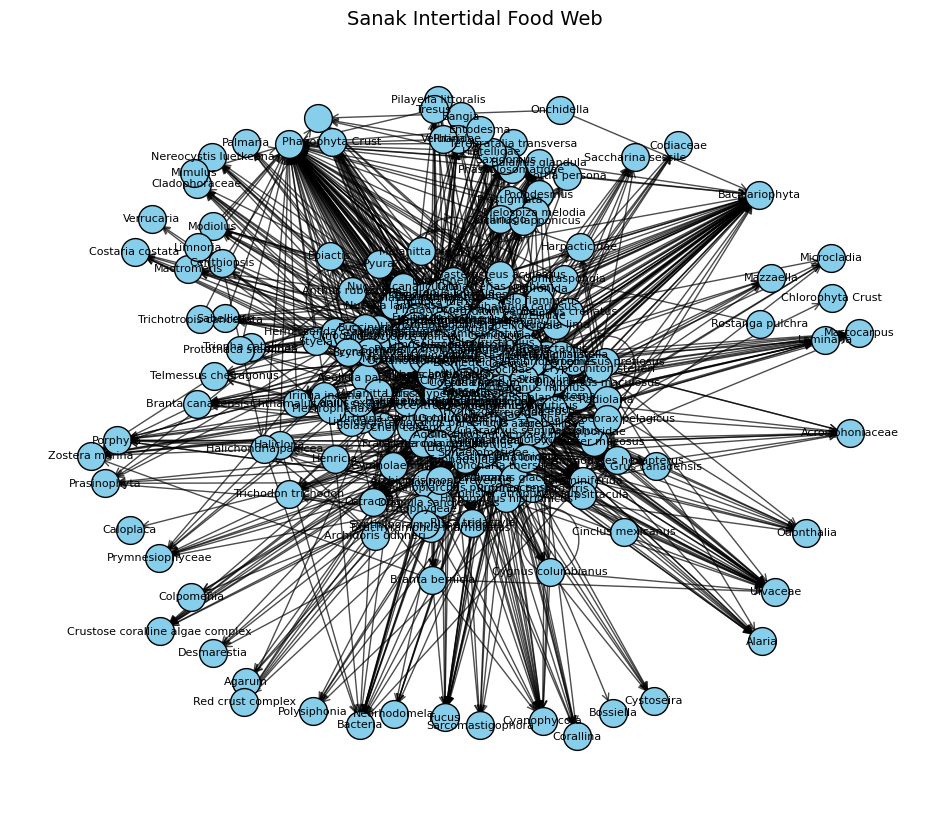

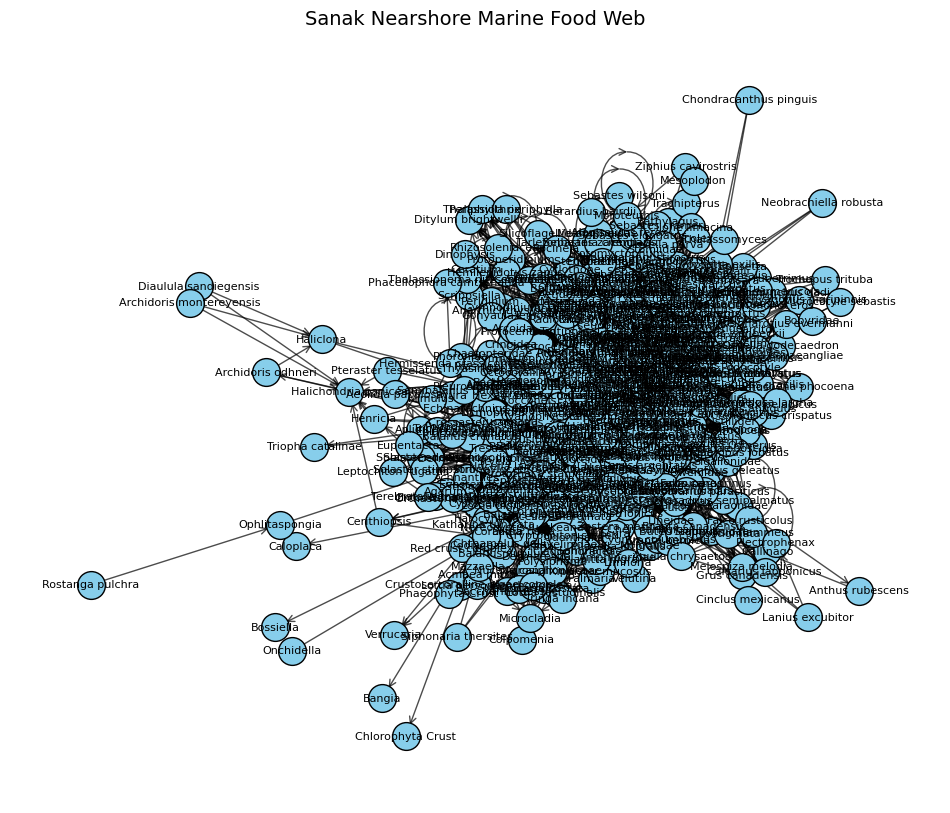

In [11]:
import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

file_path = "C:\\Users\\bogia\\OneDrive - TU Eindhoven\\study_materials\\network_statistics\\network-statistics\\Foodweb\\data.xls"
taxa_df = pd.read_excel(file_path, sheet_name="Taxa Lists", header=1)
links_df = pd.read_excel(file_path, sheet_name="Trophic Links", header=1)

taxa_intertidal = taxa_df.iloc[:, 0:4].dropna()
taxa_nearshore  = taxa_df.iloc[:, 5:9].dropna()
links_intertidal = links_df.iloc[:, 0:2].dropna()
links_nearshore  = links_df.iloc[:, 3:5].dropna()

taxa_intertidal.columns = ["ID", "TSN", "Name", "Phylum"]
taxa_nearshore.columns  = ["ID", "TSN", "Name", "Phylum"]
links_intertidal.columns = ["Consumer", "Resource"]
links_nearshore.columns  = ["Consumer", "Resource"]

G_intertidal = nx.DiGraph()
G_nearshore = nx.DiGraph()

for _, row in taxa_intertidal.iterrows():
    G_intertidal.add_node(int(row["ID"]), 
                          name=row["Name"], 
                          tsn=row["TSN"], 
                          phylum=row["Phylum"])

for _, row in taxa_nearshore.iterrows():
    G_nearshore.add_node(int(row["ID"]), 
                         name=row["Name"], 
                         tsn=row["TSN"], 
                         phylum=row["Phylum"])

for _, row in links_intertidal.iterrows():
    G_intertidal.add_edge(int(row["Consumer"]), int(row["Resource"]))

for _, row in links_nearshore.iterrows():
    G_nearshore.add_edge(int(row["Consumer"]), int(row["Resource"]))


print("Intertidal:", G_intertidal.number_of_nodes(), "nodes,", G_intertidal.number_of_edges(), "edges")
print("Nearshore:", G_nearshore.number_of_nodes(), "nodes,", G_nearshore.number_of_edges(), "edges")


def plot_graph(G, title):
    plt.figure(figsize=(12, 10))
    
    # layout for better spacing
    pos = nx.spring_layout(G, seed=42, k=0.3)  
    
    # node labels = species names
    labels = nx.get_node_attributes(G, "name")
    
    # draw nodes & edges
    nx.draw_networkx_nodes(G, pos, node_size=400, node_color="skyblue", edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="->", arrowsize=12, alpha=0.7)
    nx.draw_networkx_labels(G, pos, labels, font_size=8, font_family="sans-serif")
    
    plt.title(title, fontsize=14)
    plt.axis("off")
    plt.show()

# Plot both
plot_graph(G_intertidal, "Sanak Intertidal Food Web")
plot_graph(G_nearshore, "Sanak Nearshore Marine Food Web")

Edge (157075, 157075) set to purple
Edge (157075, 157152) set to purple
Edge (157075, 157224) set to purple
Edge (157075, 157274) set to purple
Edge (157075, 157969) set to purple
Edge (157075, 158150) set to purple
Edge (157075, 158191) set to purple
Edge (157076, 158016) set to purple
Edge (157076, 158150) set to purple
Edge (157076, 158191) set to purple
Edge (157274, 157066) set to purple
Edge (157274, 157274) set to purple
Edge (157274, 157971) set to purple
Edge (157274, 158150) set to purple
Edge (157274, 158191) set to purple
Edge (157969, 157066) set to purple
Edge (157969, 157969) set to purple
Edge (157969, 158016) set to purple
Edge (159910, 164722) set to purple
Edge (160610, 164722) set to purple
Edge (160851, 162673) set to purple
Edge (160851, 164413) set to purple
Edge (160851, 164722) set to purple
Edge (160851, 164792) set to purple
Edge (160851, 166716) set to purple
Edge (160851, 166725) set to purple
Edge (160851, 167265) set to purple
Edge (160851, 170919) set to

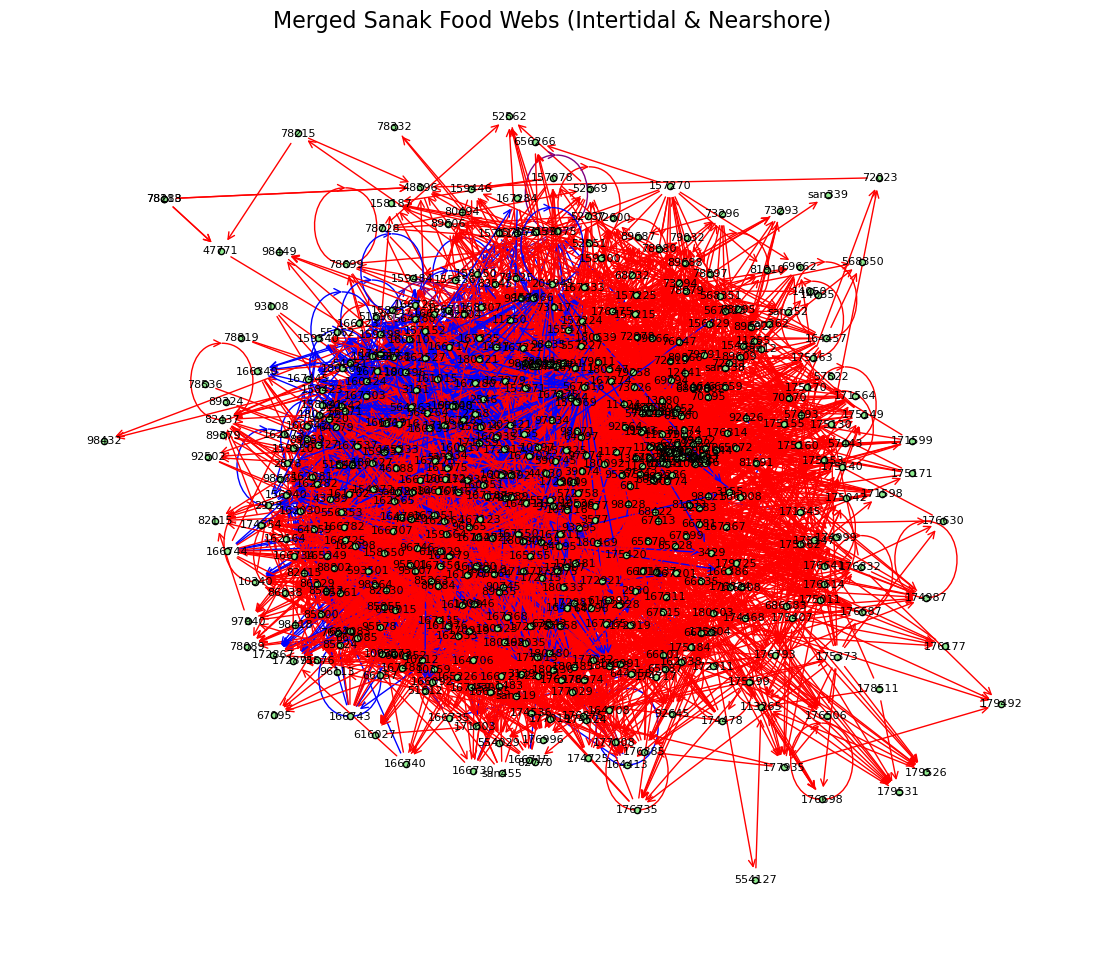

In [33]:
taxa_intertidal["ID"] = taxa_intertidal["ID"].astype(int)
taxa_nearshore["ID"] = taxa_nearshore["ID"].astype(int)
links_intertidal["Consumer"] = links_intertidal["Consumer"].astype(int)
links_intertidal["Resource"] = links_intertidal["Resource"].astype(int)
links_nearshore["Consumer"] = links_nearshore["Consumer"].astype(int)
links_nearshore["Resource"] = links_nearshore["Resource"].astype(int)

taxa_merged = pd.merge(taxa_intertidal, taxa_nearshore, on="TSN", how="outer", suffixes=("_intertidal", "_nearshore"))

G = nx.DiGraph()

# Add nodes from the merged list
for _, row in taxa_merged.iterrows():
    tsn = row["TSN"]
    name = row["Name_intertidal"] if pd.notna(row["Name_intertidal"]) else row["Name_nearshore"]
    G.add_node(tsn, name=name, TSN=tsn)

def add_edges(links_df, color):
    for _, row in links_df.iterrows():
        consumer_id = int(row["Consumer"])
        resource_id = int(row["Resource"])

        # safely get TSNs
        consumer_tsn = id_to_tsn.get(consumer_id)
        resource_tsn = id_to_tsn.get(resource_id)

        if consumer_tsn is None:
            print(f"Warning: Consumer ID {consumer_id} not found in taxa")
            continue
        if resource_tsn is None:
            print(f"Warning: Resource ID {resource_id} not found in taxa")
            continue
        
        if G.has_edge(consumer_tsn, resource_tsn):
            # If edge already exists, mark as "both"
            G[consumer_tsn][resource_tsn]["color"] = "purple"
            print(f"Edge ({consumer_tsn}, {resource_tsn}) set to purple")
        else:
            G.add_edge(consumer_tsn, resource_tsn, color=color)

# Add edges from the separate lists
add_edges(links_intertidal, "blue")
add_edges(links_nearshore, "red")


plt.figure(figsize=(14, 12))
#pos = nx.spring_layout(G, k=0.3, scale=500, seed=500)
pos = nx.kamada_kawai_layout(G, scale=5)

# Node labels
labels = nx.get_node_attributes(G, "TSN")

# Edge colors
edge_colors = [G[u][v]["color"] for u,v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=20, node_color="lightgreen", edgecolors="black")
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, arrows=True, arrowstyle="->", arrowsize=12)
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Merged Sanak Food Webs (Intertidal & Nearshore)", fontsize=16)
plt.axis("off")
plt.show()

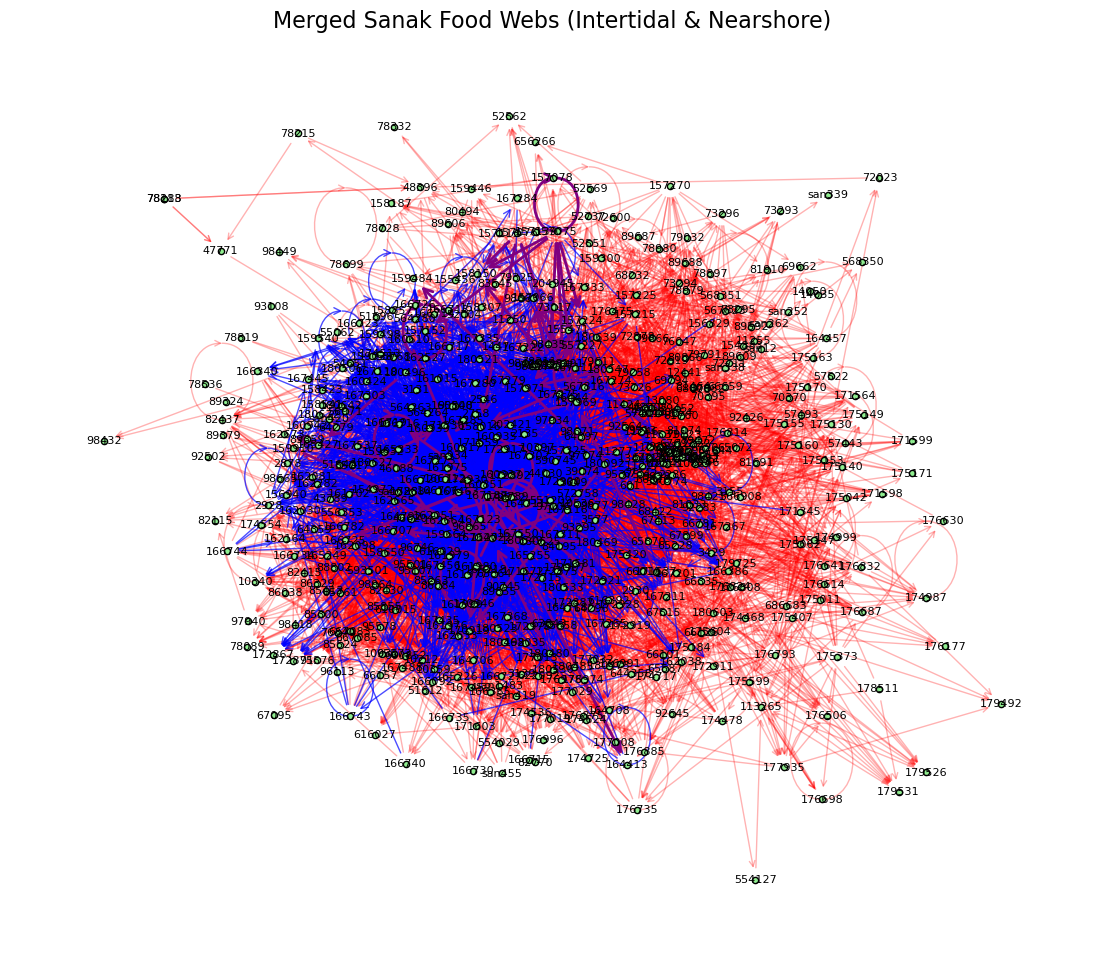

In [34]:
# Draw merged food web with edge order: purple, blue, red
plt.figure(figsize=(14, 12))
pos = nx.kamada_kawai_layout(G, scale=5)

# Node labels
labels = nx.get_node_attributes(G, "TSN")

# Separate edges by color
purple_edges = [(u, v) for u, v in G.edges() if G[u][v]["color"] == "purple"]
blue_edges = [(u, v) for u, v in G.edges() if G[u][v]["color"] == "blue"]
red_edges = [(u, v) for u, v in G.edges() if G[u][v]["color"] == "red"]

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=20, node_color="lightgreen", edgecolors="black")

# Draw edges: red (bottom), blue (middle), purple (top)
nx.draw_networkx_edges(G, pos, edgelist=red_edges, edge_color="red", arrows=True, arrowstyle="->", arrowsize=10, alpha=0.3)
nx.draw_networkx_edges(G, pos, edgelist=blue_edges, edge_color="blue", arrows=True, arrowstyle="->", arrowsize=12, alpha=0.7)
nx.draw_networkx_edges(G, pos, edgelist=purple_edges, edge_color="purple", arrows=True, arrowstyle="->", arrowsize=16, width=2)

# Draw labels
nx.draw_networkx_labels(G, pos, labels, font_size=8)

plt.title("Merged Sanak Food Webs (Intertidal & Nearshore)", fontsize=16)
plt.axis("off")
plt.show()